# The Lorenz System
The Lorenz system is a set of three ordinary differential equations, first developed by the meteorologist Edward Lorenz while studying atmospheric convection. It is a classic example of a system that can exhibit chaotic behavior, meaning its output can be highly sensitive to small changes in its starting conditions.

The Lorenz system is given by


\begin{aligned}{\frac {\mathrm {d} x}{\mathrm {d} t}}&=\sigma (y-x),\\[6pt]{\frac {\mathrm {d} y}{\mathrm {d} t}}&=x(\rho -z)-y,\\[6pt]{\frac {\mathrm {d} z}{\mathrm {d} t}}&=xy-\beta z.\end{aligned}


For certain values of its parameters, the system's solutions form a complex, looping pattern known as the Lorenz attractor. The shape of this attractor, when graphed, is famously said to resemble a butterfly. The system's extreme sensitivity to initial conditions gave rise to the popular concept of the butterfly effect—the idea that a small event, like the flap of a butterfly's wings, could ultimately alter large-scale weather patterns. While the system is deterministic—its future behavior is fully determined by its initial conditions—its chaotic nature makes long-term prediction practically impossible.

The behavior of the system depends on the choice of parameters. For some ranges of parameters, the system is predictable: trajectories settle into fixed points or simple periodic orbits, making the long-term behavior easy to describe. For example, when ρ < 1, all solutions converge to the origin, and for certain moderate values of ρ, σ, and β, solutions converge to symmetric steady states.

In contrast, for other parameter ranges, the system becomes chaotic. With the well-known parameters $\sigma = 10$, $\rho = 28$, and $\beta = 8/3$, the solutions never settle down but instead trace out the butterfly-shaped Lorenz attractor. In this regime, small differences in initial conditions grow exponentially.


<p align="center">
  <img src="Lorenz_system_r28_s10_b2-6666.png" width="700">
</p>



## Model definition and network hyperparameters

In this section, we import the required libraries and define the main
hyperparameters of the recurrent neural network, including the size of
the hidden state, input sequence length, and optimization settings.

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Recurrent Neural Network (SimpleRNN) configuration file.

This script defines the main hyperparameters and imports required
to train a recurrent neural network using TensorFlow/Keras.
"""

# =========================
# Standard Python libraries
# =========================
import time               # Timing and performance measurements
import sys                # System-specific parameters and functions

# =========================
# Scientific computing
# =========================
import numpy as np         # Numerical operations and array handling
import matplotlib.pyplot as plt  # Plotting training and test results

# =========================
# Deep Learning libraries
# =========================
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, SimpleRNN

# =========================
# Network hyperparameters
# =========================

HIDDEN_SIZE = 30
# Number of neurons in the recurrent hidden state.
# Controls the memory capacity of the RNN.

INPUT_LENGTH = 10
# Length of the input time sequence (number of time steps).

LR = 0.005
# Learning rate for the optimizer.
# Determines the step size during gradient descent.

STEP_EPOCHS = 25
# Number of epochs between learning-rate updates (if scheduling is used).

N_EPOCHS = 10
# Total number of training epochs.

BATCH_SIZE = 32
# Number of samples per gradient update.

BUFFER_SIZE = 10000
# Buffer size for shuffling the dataset.

VERBOSE = True
# If True, prints training progress and diagnostic information.



## Training configuration and dataset selection

This section defines the training setup, including the choice of dataset
size, training and test execution, and parameters controlling the
learning process.

In [ ]:
# =========================
# Training configuration
# =========================

I_SERIES = 0
# Selects the dataset to be used for training:
# 0 → 5,000 training samples
# 1 → 50,000 training samples

TEST = True
# If True, the model is evaluated on the test dataset
# and the corresponding performance metrics are reported.


## Recurrent neural network model definition

In this section, we define the architecture of the recurrent neural network
using a SimpleRNN layer followed by a fully connected output layer. The goal
is to introduce the structure of the model and understand how sequential
data are processed through the hidden state.

In [ ]:

# =========================
# Network definition
# =========================

class RNN_Net(Model):
    """
    Recurrent Neural Network (RNN) model based on a SimpleRNN layer
    followed by a fully-connected (Dense) output layer.
    We define a new class that inherits from tf.keras.Model.
    By inheriting from Model, this class becomes a full Keras model,
    meaning it can be compiled, trained, evaluated, and saved using
    model.compile(), model.fit(), model.evaluate(), model.save(), etc.
    """

    def __init__(self, input_dim, hidden_dim, batch_size, output_dim=1,
                 num_layers=1):
        """
        Constructor of the model.

        This method initializes the recurrent neural network (RNN) model and
        stores the configuration parameters that define its architecture.
        It is responsible for setting the model hyperparameters and preparing
        the components required to build the network.

        Parameters
        ----------
        self : RNN_Net
            Instance of the model.
        input_dim : int
            Number of input features per time step (i.e., the dimensionality
            of the input at each temporal step).
        hidden_dim : int
            Number of hidden units in each recurrent layer. This controls
            the capacity of the RNN to model temporal dependencies.
        batch_size : int
            Number of samples per batch. This parameter is typically required
            only when using stateful RNNs or manually handling hidden states.
        output_dim : int, optional
            Dimensionality of the model output. Defaults to 1 (e.g., scalar
            regression output).
        num_layers : int, optional
            Number of recurrent layers to be stacked in the model. Defaults
            to 1.

        Notes
        -----
        The actual network layers (e.g., RNN/LSTM/GRU and output layers) must
        be defined within this constructor, while the forward pass logic
        should be implemented in the `call()` method.
        """
        # Initialize the parent Keras Model.

        super(RNN_Net, self).__init__()

        # =========================
        # Model parameters
        # =========================

        self.input_dim = input_dim
        # Dimensionality of the input features at each time step.

        self.hidden_dim = hidden_dim
        # Number of neurons in the recurrent hidden state.

        self.batch_size = batch_size
        # Batch size used during training.

        self.output_dim = output_dim
        # Dimensionality of the output (default: scalar output).

        self.num_layers = num_layers
        # Number of recurrent layers (kept for generality).

        # =========================
        # Network layers
        # =========================

        # Recurrent layer:
        # - Processes sequential input data
        # - Uses ReLU activation (try tanh)
        # - Glorot normal initialization for stable training
        # Alternatives: LSTM or GRU
        self.rnn_in = SimpleRNN(
                units = self.hidden_dim,
                activation='relu',
                kernel_initializer='glorot_normal',
                )

        # Fully-connected output layer:
        # - Maps the hidden state to the final prediction
        self.linear = Dense(self.output_dim, activation='linear')

    # =========================
    # Forward pass definition
    # =========================
    def call(self, x):
        """
        Forward pass of the network.

        Parameters
        ----------
        x : Tensor
            Input tensor of shape (batch_size, time_steps, input_dim)

        Returns
        -------
        output : Tensor
            Network output after the linear layer.
        """

        # Feed the input sequence to the recurrent layer
        output_rnn = self.rnn_in(x)

        # Apply a linear transformation to the recurrent output
        output = self.linear(output_rnn)


        return output



## Training, validation, and autoregressive prediction

This section implements the training and validation procedures, as well as
the autoregressive prediction loop used to evaluate the model on unseen
data. Special attention is paid to the interpretation of the validation and
test losses.

In [ ]:
# =========================
# Training and testing functions
# =========================

def _validation_loss():
    """
    Computes the average validation loss over the validation dataset.
    """

    validation_loss = 0.0

    # Loop over validation batches
    for batch, (x, y) in enumerate(val_ds):

        # =========================
        # Forward pass (prediction)
        # =========================
        y_pred = net(x)
        loss_value = loss(y,y_pred)

        # Accumulate mean batch loss (accurate if all batchs are the same size)
        validation_loss += tf.math.reduce_mean(loss_value)

    # Return average validation loss
    return validation_loss / validation_steps


def predict(X, Y):
    """
    Performs autoregressive prediction on the test dataset.

    At each time step, the network prediction is fed back as input
    to generate the next prediction.

    Parameters
    ----------
    X : ndarray
        Input test data.
    Y : ndarray
        Ground-truth output data.

    Returns
    -------
    X_pred : ndarray
        Predicted time series.
    total_test_loss : ndarray
        Test loss at each prediction step.
    """

    # Array to store the test loss at each prediction step
    total_test_loss = np.ndarray((n_test,), dtype='float')

    # Timing the prediction process
    t_start = time.time()

    # Initial input sequence for autoregressive prediction
    x_pr = X[0]

    # =========================
    # Autoregressive prediction loop
    # =========================
    for i_pred in range(n_test):

        # Build input sequence for the current prediction step
        x_pred = x_pr[i_pred:p+i_pred].reshape((1, p, 3))

        # Forward pass through the network
        y_pred = net.predict(x_pred, batch_size=1,verbose=0)

        # Se puede usar
        # y_pred = net(x_pred, training=False).numpy()



        # Compute prediction error
        test_loss = loss(y_pred, Y[i_pred])
        total_test_loss[i_pred] = test_loss.numpy()

        # Append the prediction to the input sequence
        x_pr = np.concatenate((x_pr, y_pred), axis=0)

    # End timing
    t_end = time.time()
    print('Elapsed time: ' + str(t_end - t_start) + ' s')

    return x_pr.T, total_test_loss


## Data pre-processing and sequence generation

In this section, the raw time-series data are transformed into input–output
pairs suitable for training a recurrent neural network. The preprocessing
is based on a sliding-window approach, where sequences of length `p` are used
as input features and the target corresponds to the next time step in the
series.

This procedure allows the network to learn temporal dependencies and
enables autoregressive prediction during testing.


In [ ]:
# =========================
# Data pre-processing
# =========================

def preprocess_data_recurrent(i_ser, p):
    """
    Prepares time-series data for training a recurrent neural network.

    The function constructs input sequences of length p (sliding windows)
    and the corresponding targets at the next time step.

    Parameters
    ----------
    i_ser : int
        Index indicating which time series dataset is loaded.
    p : int
        Number of time steps in each input sequence.

    Returns
    -------
    processed_features : ndarray
        Array of input sequences with shape (T - p, p, 3).
    output_targets : ndarray
        Array of target values at the next time step with shape (T - p, 3).
    """

    # Load the selected time series # 04d Format to be written
    t_series = np.load(f'series_{i_ser:04d}.npz')['tseries']
    time_series = t_series

    # Total number of time steps
    T = time_series.shape[1]

    # Allocate arrays for inputs and targets
    processed_features = np.ndarray((T - p, p, 3), float)
    output_targets = np.ndarray((T - p, 3), float)

    # =========================
    # Sliding window generation
    # =========================
    for i_p in range(0, T - p):
        for i_coeff in range(3):

            # Input sequence of length p for each coefficient
            processed_features[i_p, :, i_coeff] = \
                time_series[i_coeff, i_p:i_p + p]

            # Target value at the next time step
            output_targets[i_p, i_coeff] = \
                time_series[i_coeff, i_p + p]

    return processed_features, output_targets


## Main execution, training, and evaluation

In this final section, all previously defined components are combined into a
complete workflow. The time-series data are preprocessed, the recurrent neural
network is instantiated, and the model is trained using the selected training
and validation datasets.

During training, both the training and validation losses are monitored in order
to assess convergence and detect possible overfitting. The evolution of these
losses is visualized on a logarithmic scale.

Finally, the trained model is evaluated through autoregressive prediction on
unseen test data. The predicted trajectories are compared against the reference
data, and the temporal evolution of the test error is analyzed to assess the
stability and long-term performance of the recurrent network.


%% Epoch:1/10
  1/157 ━━━━━━━━━━━━━━━━━━━━ 2:30 967ms/step - train loss: 251.2951

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['seed_generator/seed_generator_state'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - train loss: 0.4137
validation loss: 5.9299e-01
%% Epoch:2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - train loss: 0.2465
validation loss: 3.0274e-01
%% Epoch:3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - train loss: 0.1038
validation loss: 1.7809e-01
%% Epoch:4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - train loss: 0.0332
validation loss: 9.4362e-02
%% Epoch:5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - train loss: 0.2223
validation loss: 1.1555e-01
%% Epoch:6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - train loss: 0.0480
validation loss: 5.7727e-02
%% Epoch:7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - train loss: 0.0355
validation loss: 5.4141e-02
%% Epoch:8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - train loss: 0.0225
validation loss: 5.6448e-02
%% Epoch:9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - train loss: 0.0717
validation loss: 1.1531e-01
%% Epoch:10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step 

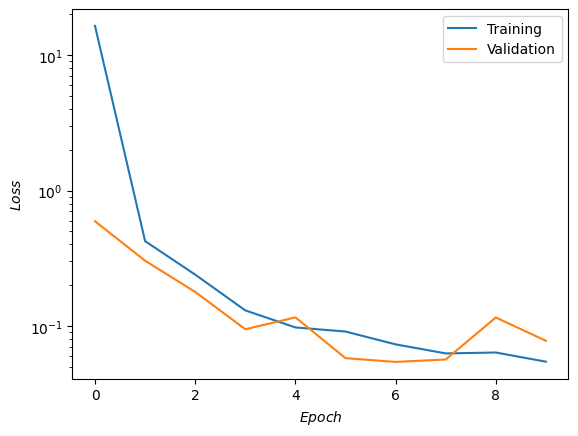

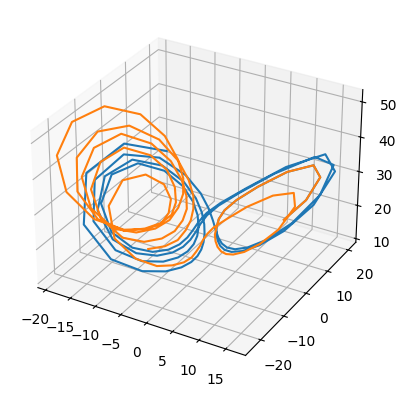

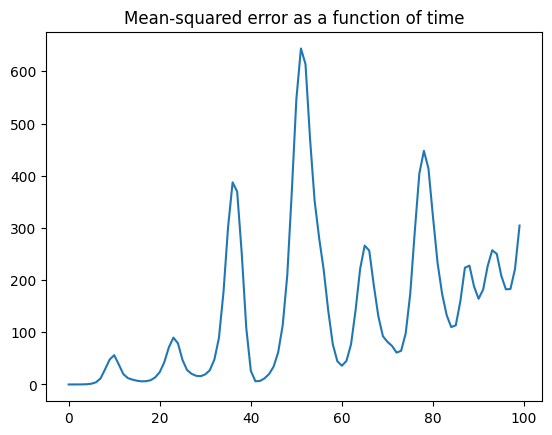

In [ ]:

# =========================
# Main execution block
# =========================

if __name__ == '__main__':

    # =========================
    # General configuration
    # =========================

    p = INPUT_LENGTH
    # Length of the input sequence used by the RNN

    verbose = VERBOSE
    # Controls the verbosity level during training

    epochs = N_EPOCHS
    # Total number of training epochs

    # =========================
    # Data loading and preprocessing
    # =========================

    X, Y = preprocess_data_recurrent(I_SERIES, p)

    # Define training, validation, and test sizes
    n_train = int(10**np.floor(np.log10(X.shape[0])) / 2)
    n_val = n_train
    n_test = X.shape[0] - n_train * 2

    # Number of steps per epoch
    steps_per_epoch = int(np.ceil(n_train / BATCH_SIZE))
    validation_steps = int(np.ceil(n_val / BATCH_SIZE))

    # =========================
    # Dataset construction
    # =========================

    train_ds = tf.data.Dataset.from_tensor_slices(
        (X[:n_train], Y[:n_train])
    )

    # Shuffle the training dataset
    train_ds = train_ds.shuffle(BUFFER_SIZE)

    # Divide into batches
    train_ds = train_ds.batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices(
        (X[n_train:n_train + n_val],
         Y[n_train:n_train + n_val])
    )

    # Batch the validation dataset
    val_ds = val_ds.batch(BATCH_SIZE)

    # Test data (kept untouched)
    X_test = X[-n_test:]
    Y_test = Y[-n_test:]

    # =========================
    # Model, loss, and optimizer
    # =========================

    # Build the RNN model
    net = RNN_Net((p,3), HIDDEN_SIZE, batch_size = BATCH_SIZE,
                  output_dim = 3, num_layers = 1)

    # Define the loss function
    loss = tf.keras.losses.MeanSquaredError()

    # Define a learning-rate schedule (optional)
    # Improves training, reducing the LR
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
                LR,
                decay_steps=int(steps_per_epoch*STEP_EPOCHS),
                decay_rate=0.5,
                staircase=True)

    # Define the optimizer (e.g., Adam- Try AdamW or SGD)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    # List of commonly used optimizers and when to use them

    optimizers_list = [
        # Adam optimizer with learning-rate schedule
        # Fast convergence, good default choice for most problems
        tf.keras.optimizers.Adam(learning_rate=lr_schedule),

        # AdamW optimizer (Adam with decoupled weight decay)
        # Improves generalization, recommended for CNNs and autoencoders
        tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),

        # Adam with gradient clipping
        # Useful to stabilize training in RNNs and Koopman autoencoders
        tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0),

        # SGD with momentum and Nesterov acceleration
        # More interpretable, often better generalization in vision tasks
        tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9, nesterov=True),

        # RMSprop optimizer
        # Well suited for time-series and recurrent models
        tf.keras.optimizers.RMSprop(learning_rate=lr_schedule),

        # Nadam optimizer (Adam + Nesterov momentum)
        # Sometimes converges faster than Adam
        tf.keras.optimizers.Nadam(learning_rate=lr_schedule),
]


    # =========================
    # Model training
    # =========================

    history_train_loss = []
    history_val_loss = []
    for epoch in range(N_EPOCHS):

        # Two different verbosity modes:
        # VERBOSE == 0 → minimal output with timing and averaged losses
        # VERBOSE != 0 → progress bar updated at each batch
        if VERBOSE == 0:
            # Metrics to accumulate mean training and validation loss
            t_loss = tf.keras.metrics.Mean('train_loss', dtype=tf.float32)
            v_loss = tf.keras.metrics.Mean('validation_loss', dtype=tf.float32)

            # Start timing the epoch
            t_start = time.time()
        else:
            # Manual accumulation of the training loss
            t_loss = 0

            # Progress bar for batch-wise visualization
            progbar = tf.keras.utils.Progbar(
            steps_per_epoch,
            stateful_metrics=["train loss"]
            )
        # Print epoch counter
        print(f'%% Epoch:{epoch+1:d}/{N_EPOCHS:d}')

            # Loop over batches in the training dataset
        for batch, (x, y) in enumerate(train_ds.take(steps_per_epoch)):
            # Remove unnecessary singleton dimensions from the target
            y = tf.squeeze(y) # (3,1,3) → (3,3)

            # Record operations for automatic differentiation
            with tf.GradientTape() as tape:
                # Forward pass: compute model predictions
                    y_pred = net(x)

                # Compute the loss between predictions and ground truth
                    loss_value = loss(y, y_pred)
                        # Compute gradients of the loss with respect to model parameters

            grads = tape.gradient(loss_value, net.variables)

            # Apply gradients to update the model weights
            optimizer.apply_gradients(zip(grads, net.variables))

            # Update training loss statistics
            if VERBOSE == 0:
                t_loss.update_state(loss_value)
            else:
                t_loss += loss_value
                progbar.add(1, values=[("train loss", loss_value)])
             # -------------------------

        # End of epoch
        # -------------------------
        if VERBOSE == 0:
            # End timing
            t_end = time.time()

            # Compute validation loss for the current epoch
            v_loss.update_state(_validation_loss())

            # Print epoch summary
            print(
                f"{t_end-t_start:.2f} s - "
                f"training loss: {t_loss.result():.4e} - "
                f"validation loss: {v_loss.result():.4e}",
                flush=True
            )

            # Store loss history
            history_train_loss.append(t_loss.result().numpy())
            history_val_loss.append(v_loss.result().numpy())

        else:
            # Average training loss over all steps
            t_loss /= steps_per_epoch
            history_train_loss.append(t_loss.numpy())
            t_loss = 0

            # Compute and store validation loss
            v_loss = _validation_loss()
            print(f"validation loss: {v_loss:.4e}")
            history_val_loss.append(v_loss.numpy())

    # -------------------------
    # Plot training history
    # -------------------------
    fig = plt.figure()
    ax = fig.add_subplot(111)

    # Plot training and validation loss as a function of epoch
    ax.plot(history_train_loss, label='Training')
    ax.plot(history_val_loss, label='Validation')

    ax.legend()
    ax.set(
        xlabel='$Epoch$',
        ylabel='$Loss$',
        yscale='log'
    )

    # Exit if test phase is disabled
    if TEST == False:
        sys.exit(0)

    # %% Prediction
    # Run the model on the test dataset and compute the test loss
    X_pred, test_loss = predict(X_test, Y_test)

    # 3D visualization of true trajectory vs predicted trajectory
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(
        X_test[:100, 0, 0],
        X_test[:100, 0, 1],
        X_test[:100, 0, 2]
    )
    ax.plot(
        X_pred[0, :100],
        X_pred[1, :100],
        X_pred[2, :100]
    )

    # Plot the test loss as a function of time
    fig = plt.figure()
    ax = fig.add_subplot(111)

    ax.plot(test_loss[:100])
    ax.set(title='Mean-squared error as a function of time')

    plt.show()




## Conclusions and discussion

In this notebook, a recurrent neural network (RNN) has been implemented and
trained to model and predict multivariate time-series data. Through the use of
sliding-window preprocessing and autoregressive prediction, the network is able
to learn temporal dependencies from the data.

The results highlight the role of the hidden state in capturing memory effects
and demonstrate the limitations of simple RNN architectures when performing
long-term predictions, as evidenced by the growth and intermittency of the test
error.

Comparisons between different training configurations show that the learning
rate, the use of learning-rate schedules, and the dimensionality of the hidden
state have a significant impact on training stability and generalization
performance.

Overall, this exercise illustrates the strengths and weaknesses of recurrent
neural networks and provides a natural motivation for more advanced architectures
such as Long Short-Term Memory (LSTM) and Gated Recurrent Units (GRU), which are
designed to better control information flow and mitigate error accumulation over
time.
